# Getting started

## First steps

Let's import **scaleo**, create a sample signal and add some Gaussian noise to get closer to natural examples. Let's create a signal from three separate pulses of different frequencies and segments on the time scale.

Create instance of CWT class with sample signal, compute Continuous Wavelet Transform (**CWT**) and draw a complex plot to see both sample signal and correspondind scaleogram aligned by time ticks.

In [1]:
import numpy as np
import sys
from pathlib import Path
# shim for working with local copy
if str(Path.cwd().parent.parent.name) == 'scaleo':
    parent_dir = str(Path.cwd().parent.parent.parent)
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

from scaleo import CWT

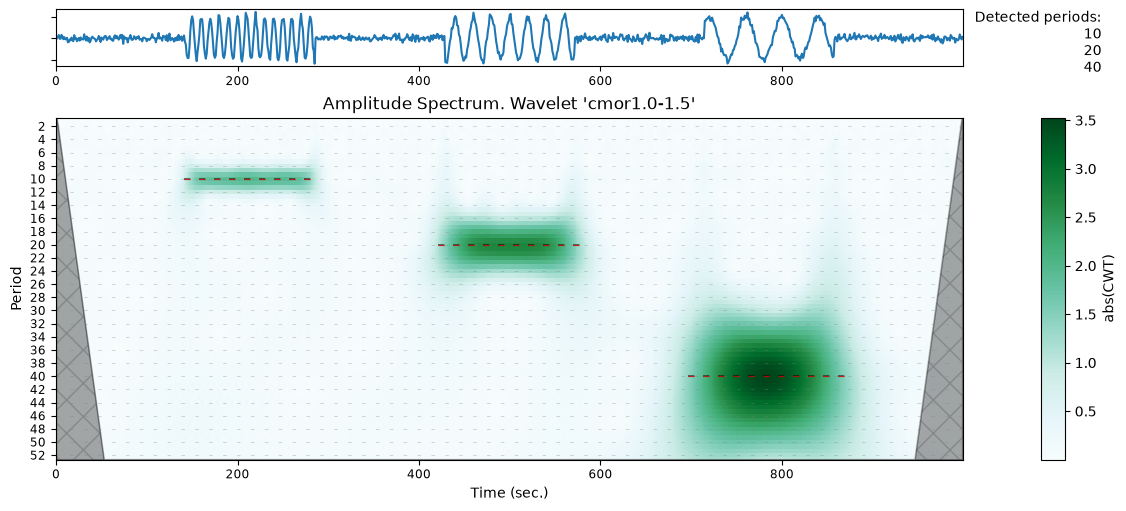

In [2]:
np.random.seed(42)
# Generate a clean sine wave vector and inject random noise
fs = 1                  # Sampling frequency (Hz)
duration = 1000         # time period in sec
ns = duration * fs       # number of samples
time = np.arange(ns)
steps  = np.linspace(0, ns, 8)
periods = [10, 20, 40]
pulses = np.zeros(ns, dtype=np.float32)
for i in range(0,3):
    step_mask = (time > steps[i*2+1]) & (time < steps[i*2+2])
    pulses += np.cos(2*np.pi/periods[i]*time) * step_mask      # Perios: 0.2PI sec = 0.628Hz, 0.1PI sec =  0.314, 0.05PI sec = 0.157Hz
noisy_vector = pulses + np.random.normal(0, 0.1, len(time))  #  Gausian noise
# noisy_vector = clean_signal + np.random.uniform(-0.1, 0.1, len(t))  #  Uniform Noise
cwt = CWT(noisy_vector, fs, time, 'cmor1.0-1.5', xlabel='Time (sec.)')
cwt.cwt(scales=np.arange(1, 80))
cwt.complex_plot(figsize=(11,5), cmap='BuGn', detect_peaks=True)

## Customization

### Class methods

Now let's look into details. You need to create an instance of class **CWT**:

>*class* **scaleo.CWT**
>
>**\_\_init_\_**(signal_data: list | ndarray, sampling_freq: float, time_ticks: list | ndarray | None = None, wavelet_name: str = 'cmor1.5-1.0', xlabel: str | None = None)
>
>**Parameters:**
>  * **signal_data** (*list* *or* *np.ndarray*) – The input signal values.
>  * **sampling_freq** (*float*) – The sampling frequency of the signal.
>  * **time_ticks** (*list* *or* *np.ndarray* *or* *None* *,* *optional*) – The time ticks corresponding to the signal values.
>    If None then will be initialized as array of values [0…1]. Defaults to None.
>  * **wavelet_name** (*str* *,* *optional*) – The name of the wavelet to use. Defaults to ‘cmor1.5-1.0’.
>    See ``pywt.wavelist(kind='continuous')`` to get full list of wavelets.
>  * **xlabel** (*str* *or* *None* *,* *optional*) – A custom text for x-axis (time-axis). Defaults to None.

---

Then we run CWT via method ```cwt(..)``` and our own list of scales. You can pass your own list of scales, periods or bounds of frequencies. Description of the method:

>**cwt**(scales: ndarray | list | tuple[float, float] | None = None, periods: ndarray | list | tuple = None, min_max_freq: tuple[float, float] | None = None, method: str = 'conv') → tuple[ndarray, ndarray]
>
>**Parameters:**
>  * **scales** (*tuple* *,* *optional*) – Array of scales for CWT. If None and other inputs is None, then an attempt will be made to select scales based on fs and the length of the observation time series.
>    Note: If all param’s is None, then the range of frequencies between [1/time_window, fs/2] will be used.
>  * **periods** (*set* *,* *optional*) – Array of periods to compute appropriate scales for CWT. Defaults to None.
>  * **min_max_freq** (*tuple* *,* *optional*) – A tuple of two floats: the minimum and maximum frequencies to generate range between and use in computation.
>    Applicable only if both scales=\`None\` and periods=\`None\`. Defaults to None.
>  * **method** (*str*) – cwt method. Can be ‘conv’ or ‘fft’. See [https://pywavelets.readthedocs.io/en/latest/ref/cwt.html](https://pywavelets.readthedocs.io/en/latest/ref/cwt.html) Defaults to ‘conv’
>* **Returns:**
>  A tuple containing the CWT coefficients and according frequencies which is result of calling pywt.cwt(..)

---

And at the end we draw a scaleogram. There are two methods:

1. ```scalogram(..)``` - draw only a scalogram.
2. ```complex_plot(..)``` - constructing a complex graph with the original signal and the calculation results.

The parameters of both methods are similar. Here's what the complete set of method parameters looks like:

>**scalogram**(ax=None, ticktype: str = 'period', spectrum: str = 'amp', cmap='PRGn', logscale: bool = False, figsize: tuple = (10, 5), cbar: bool = True, cbar_ax=None, coi: bool = True, coi_alpha: float = 0.35, >  > twinticks: str | None = None, ygrid: bool = True, vmin: float | None = None, vmax: float | None = None)
>
>**Parameters:**
>  * **ax** (*Any*) – Matplotlib axes. If None, then own Matplotlib canvas will be created. Defaults None.
>  * **ticktype** (*str* *,* *optional*) – Type of Y-axes. One of the following predefined values: ‘scale’, ‘period’, ‘freq’. Defaults ‘period’.
>  * **spectrum** (*str* *,* *optional*) – Type of spectrum image. One of the following predefined values: ‘amp’ for amplitude,
>    ‘real’ for use real part, ‘imag’ for use imaginary part of values, ‘power’ for spectrum based on power of signal. Defaults ‘amp’.
>  * **cmap** (*Any* *,* *optional*) – Matplotlib colormap. Defaults ‘PRGn’. See: https://matplotlib.org/stable/gallery/color/colormap_reference.html
>  * **logscale** (*bool* *,* *optional*) – If True logarithmic scale will be used.
>  * **figsize** (*tupl* *,* *optional*) – Matplotlib ‘figsize’ parameter. Defaults (10,5).
>  * **cbar** (*boo* *,* *optionall*) – If True then cbar legend will be append. If ‘twinticks’ parameter is not None and ‘cbar_ax’ not provided, then this parameter is omitted. Defaults True.
>  * **cbar_ax** (*Any* *,* *optional*) – If provided, then legend will be drawed in this matplotlib context. Defaults None.
>  * **coi** (*bool* *,* *optional*) – If True, then the Cone of Influence will be drawn above scalogram. Defaults True.
>  * **coi_alpha** (*floatm optional*) – Opacity for COI. Defaults 0.35
>  * **twinticks** (*str* *,* *optional*) – If not None second Y-axes to the right will be append. Values is predefined and same as for ‘ticktype’ parameter. Defaults None.
>  * **ygrid** (*bool* *,* *optional*) – If True then grid lines will be added to plot. Defaults True
>  * **vmin** (*float* *or* *None* *,* *optional*) – If not None, then use this value as minimum for image color and colorbar. Defaults None.
>  * **vmax** (*float* *or* *None* *,* *optional*) – If not None, then use this value as maximum for image color and colorbar. Defaults None.
>* **Returns:**
>  None

---

### Draw a customized Scalogram

Let's create a new signal by adding two different sinusoids and display a scalogram with simultaneous labels for both scales and frequencies. This time we will use a logarithmic scale along the Y-axis so that the bandwith will have the same visual height at all scales. We will also slightly adjust the wavelet parameters.

In this example, the first sine wave has a period of **20** seconds, the second one is four times smaller.

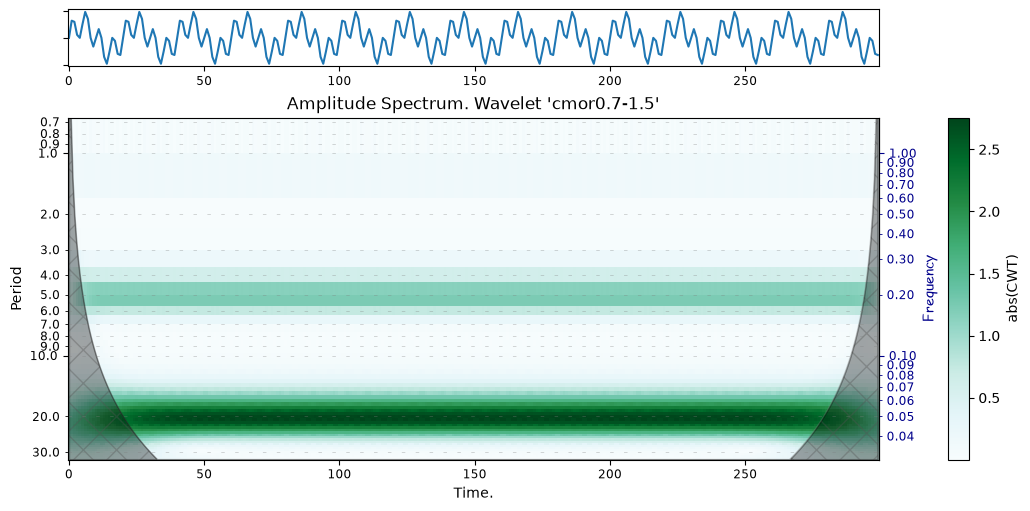

---------- 
Detected dominant periods: [5.33, 20.67]


In [9]:
fs = 1                        # Sampling frequency (Hz)
time_period = 300             # time period in sec
np.random.seed(42)
t = np.linspace(0, time_period, int(time_period * fs), endpoint=False)
p1 = 20; f1 = 1./p1;
# p2 = 60; f2 = 1./p2;
clean_signal = np.sin(2*np.pi/p1*t) + np.sin(8*np.pi/p1*t)
cwt = CWT(clean_signal, fs, t, 'cmor0.7-1.5')
cwt.cwt(scales=np.arange(1, 50))
cwt.complex_plot(figsize=(10,5), cmap='BuGn', ticktype='period', twinticks='freq', logscale=True, detect_peaks=False)

dominant_periods = [float(round(x,2)) for x in cwt.detect_power_peaks()]
print("-"*10, f"\nDetected dominant periods: {dominant_periods}")